# Cell 1 — Load Engineered Data & Setup

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().parent

FEATURE_DIR = PROJECT_ROOT / "models" / "features"

X_train = pd.read_csv(FEATURE_DIR / "X_train.csv")
X_test = pd.read_csv(FEATURE_DIR / "X_test.csv")

y_train = pd.read_csv(FEATURE_DIR / "y_train.csv").squeeze("columns")
y_test = pd.read_csv(FEATURE_DIR / "y_test.csv").squeeze("columns")

feature_columns = pd.read_csv(
    FEATURE_DIR / "feature_columns.csv"
)["Feature"].tolist()

X_train = X_train[feature_columns]
X_test = X_test[feature_columns]

print("=" * 80)
print("FORESIGHT — MODEL EXPERIMENTS SETUP")
print("=" * 80)

print("\nProject Root:")
print(PROJECT_ROOT)

print("\nFeature Directory:")
print(FEATURE_DIR)

print("\nTraining Data:")
print(X_train.shape)

print("\nTesting Data:")
print(X_test.shape)

print("\nTraining Target:")
print(y_train.shape)

print("\nTesting Target:")
print(y_test.shape)

print("\nNumber of Features:")
print(len(feature_columns))

print("\nMissing Values:")
print("X_train:", X_train.isna().sum().sum())
print("X_test :", X_test.isna().sum().sum())
print("y_train:", y_train.isna().sum())
print("y_test :", y_test.isna().sum())

print("\nFeature Alignment:")
print(X_train.columns.equals(X_test.columns))

print("\n✅ Model experiment setup completed successfully.")

FORESIGHT — MODEL EXPERIMENTS SETUP

Project Root:
d:\Zidio project\FORESIGHT Project

Feature Directory:
d:\Zidio project\FORESIGHT Project\models\features

Training Data:
(28960, 130)

Testing Data:
(7240, 130)

Training Target:
(28960,)

Testing Target:
(7240,)

Number of Features:
130

Missing Values:
X_train: 0
X_test : 0
y_train: 0
y_test : 0

Feature Alignment:
True

✅ Model experiment setup completed successfully.


# Cell 2 — Baseline Forecasting Model.

In [2]:
baseline_prediction = np.full(
    len(y_test),
    y_train.mean()
)

baseline_mae = np.mean(
    np.abs(y_test - baseline_prediction)
)

baseline_rmse = np.sqrt(
    np.mean(
        (y_test - baseline_prediction) ** 2
    )
)

non_zero_actuals = y_test != 0

if non_zero_actuals.sum() > 0:
    baseline_mape = np.mean(
        np.abs(
            (y_test[non_zero_actuals] - baseline_prediction[non_zero_actuals])
            / y_test[non_zero_actuals]
        )
    ) * 100
else:
    baseline_mape = np.nan

ss_res = np.sum(
    (y_test - baseline_prediction) ** 2
)

ss_tot = np.sum(
    (y_test - y_test.mean()) ** 2
)

baseline_r2 = (
    1 - (ss_res / ss_tot)
    if ss_tot != 0
    else np.nan
)

baseline_metrics = pd.DataFrame({
    "Model": ["Baseline"],
    "MAE": [baseline_mae],
    "RMSE": [baseline_rmse],
    "MAPE": [baseline_mape],
    "R2": [baseline_r2]
})

print("=" * 80)
print("BASELINE FORECASTING MODEL")
print("=" * 80)

print(f"\nTraining Mean Demand: {y_train.mean():.2f}")

print("\nBaseline Metrics:")
display(baseline_metrics)

print("\nSample Predictions:")
baseline_comparison = pd.DataFrame({
    "Actual": y_test.iloc[:10].values,
    "Predicted": baseline_prediction[:10]
})

display(baseline_comparison)

print("\n✅ Baseline model completed successfully.")

BASELINE FORECASTING MODEL

Training Mean Demand: 13.63

Baseline Metrics:


,Model,MAE,RMSE,MAPE,R2
0,Baseline,7.137636,8.941067,67.39007,-0.047219



Sample Predictions:


,Actual,Predicted
0,13.0,13.626278
1,12.0,13.626278
2,8.0,13.626278
3,8.0,13.626278
4,7.0,13.626278
5,16.0,13.626278
6,16.0,13.626278
7,8.0,13.626278
8,14.0,13.626278
9,5.0,13.626278



✅ Baseline model completed successfully.


# Cell 3 — Linear Regression Model.

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_prediction = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_prediction)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_prediction)
)

non_zero_actuals = y_test != 0

if non_zero_actuals.sum() > 0:
    linear_mape = np.mean(
        np.abs(
            (y_test[non_zero_actuals] - linear_prediction[non_zero_actuals])
            / y_test[non_zero_actuals]
        )
    ) * 100
else:
    linear_mape = np.nan

linear_r2 = r2_score(y_test, linear_prediction)

linear_metrics = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [linear_mae],
    "RMSE": [linear_rmse],
    "MAPE": [linear_mape],
    "R2": [linear_r2]
})

print("=" * 80)
print("LINEAR REGRESSION MODEL")
print("=" * 80)

print("\nModel Training:")
print("Training rows:", X_train.shape[0])
print("Features:", X_train.shape[1])

print("\nLinear Regression Metrics:")
display(linear_metrics)

linear_comparison = pd.DataFrame({
    "Actual": y_test.iloc[:10].values,
    "Predicted": linear_prediction[:10]
})

print("\nSample Predictions:")
display(linear_comparison)

print("\n✅ Linear Regression model completed successfully.")

LINEAR REGRESSION MODEL

Model Training:
Training rows: 28960
Features: 130

Linear Regression Metrics:


,Model,MAE,RMSE,MAPE,R2
0,Linear Regression,3.294855,4.291307,31.386581,0.758766



Sample Predictions:


,Actual,Predicted
0,13.0,7.757110
1,12.0,10.492128
2,8.0,11.703130
3,8.0,11.943944
4,7.0,11.789890
5,16.0,11.848923
6,16.0,12.077689
7,8.0,10.682145
8,14.0,11.382102
9,5.0,10.953449



✅ Linear Regression model completed successfully.


# Cell 4 — Random Forest Model

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

random_forest_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

rf_prediction = random_forest_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_prediction)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_prediction)
)

non_zero_actuals = y_test != 0

if non_zero_actuals.sum() > 0:
    rf_mape = np.mean(
        np.abs(
            (y_test[non_zero_actuals] - rf_prediction[non_zero_actuals])
            / y_test[non_zero_actuals]
        )
    ) * 100
else:
    rf_mape = np.nan

rf_r2 = r2_score(y_test, rf_prediction)

rf_metrics = pd.DataFrame({
    "Model": ["Random Forest"],
    "MAE": [rf_mae],
    "RMSE": [rf_rmse],
    "MAPE": [rf_mape],
    "R2": [rf_r2]
})

print("=" * 80)
print("RANDOM FOREST MODEL")
print("=" * 80)

print("\nModel Training:")
print("Training rows:", X_train.shape[0])
print("Features:", X_train.shape[1])

print("\nRandom Forest Metrics:")
display(rf_metrics)

rf_comparison = pd.DataFrame({
    "Actual": y_test.iloc[:10].values,
    "Predicted": rf_prediction[:10]
})

print("\nSample Predictions:")
display(rf_comparison)

print("\n✅ Random Forest model completed successfully.")

RANDOM FOREST MODEL

Model Training:
Training rows: 28960
Features: 130

Random Forest Metrics:


,Model,MAE,RMSE,MAPE,R2
0,Random Forest,3.197495,4.123301,30.360426,0.777285



Sample Predictions:


,Actual,Predicted
0,13.0,5.205351
1,12.0,11.792334
2,8.0,11.446134
3,8.0,11.545162
4,7.0,11.448095
5,16.0,12.779502
6,16.0,11.884247
7,8.0,10.544957
8,14.0,11.317264
9,5.0,10.314438



✅ Random Forest model completed successfully.


# Cell 5 — LightGBM Model

In [5]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

lightgbm_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

lightgbm_model.fit(
    X_train,
    y_train
)

lgbm_prediction = lightgbm_model.predict(X_test)

lgbm_mae = mean_absolute_error(
    y_test,
    lgbm_prediction
)

lgbm_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lgbm_prediction
    )
)

non_zero_actuals = y_test != 0

if non_zero_actuals.sum() > 0:
    lgbm_mape = np.mean(
        np.abs(
            (
                y_test[non_zero_actuals]
                - lgbm_prediction[non_zero_actuals]
            )
            / y_test[non_zero_actuals]
        )
    ) * 100
else:
    lgbm_mape = np.nan

lgbm_r2 = r2_score(
    y_test,
    lgbm_prediction
)

lgbm_metrics = pd.DataFrame({
    "Model": ["LightGBM"],
    "MAE": [lgbm_mae],
    "RMSE": [lgbm_rmse],
    "MAPE": [lgbm_mape],
    "R2": [lgbm_r2]
})

print("=" * 80)
print("LIGHTGBM MODEL")
print("=" * 80)

print("\nModel Training:")
print("Training rows:", X_train.shape[0])
print("Features:", X_train.shape[1])

print("\nLightGBM Metrics:")
display(lgbm_metrics)

lgbm_comparison = pd.DataFrame({
    "Actual": y_test.iloc[:10].values,
    "Predicted": lgbm_prediction[:10]
})

print("\nSample Predictions:")
display(lgbm_comparison)

print("\n✅ LightGBM model completed successfully.")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009229 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4333
[LightGBM] [Info] Number of data points in the train set: 28960, number of used features: 130
[LightGBM] [Info] Start training from score 13.626278
LIGHTGBM MODEL

Model Training:
Training rows: 28960
Features: 130

LightGBM Metrics:


,Model,MAE,RMSE,MAPE,R2
0,LightGBM,3.178223,4.134029,29.450943,0.776125



Sample Predictions:


,Actual,Predicted
0,13.0,6.655836
1,12.0,12.305798
2,8.0,11.464484
3,8.0,11.764276
4,7.0,11.259979
5,16.0,12.792320
6,16.0,12.422881
7,8.0,10.915859
8,14.0,10.858354
9,5.0,10.352311



✅ LightGBM model completed successfully.


# Cell 6 — Model Comparison & Best Model Selection

In [6]:
model_comparison = pd.concat(
    [
        baseline_metrics,
        linear_metrics,
        rf_metrics,
        lgbm_metrics
    ],
    ignore_index=True
)

print("=" * 80)
print("MODEL COMPARISON")
print("=" * 80)

display(
    model_comparison.style.format({
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}",
        "MAPE": "{:.2f}%",
        "R2": "{:.4f}"
    })
)

best_mae_model = model_comparison.loc[
    model_comparison["MAE"].idxmin(),
    "Model"
]

best_rmse_model = model_comparison.loc[
    model_comparison["RMSE"].idxmin(),
    "Model"
]

best_mape_model = model_comparison.loc[
    model_comparison["MAPE"].idxmin(),
    "Model"
]

best_r2_model = model_comparison.loc[
    model_comparison["R2"].idxmax(),
    "Model"
]

print("\nBest MAE Model  :", best_mae_model)
print("Best RMSE Model :", best_rmse_model)
print("Best MAPE Model :", best_mape_model)
print("Best R² Model   :", best_r2_model)

ml_models = model_comparison[
    model_comparison["Model"] != "Baseline"
].copy()

ml_models["Rank_Score"] = (
    ml_models["MAE"].rank(ascending=True)
    + ml_models["RMSE"].rank(ascending=True)
    + ml_models["MAPE"].rank(ascending=True)
    + ml_models["R2"].rank(ascending=False)
)

best_model_name = ml_models.loc[
    ml_models["Rank_Score"].idxmin(),
    "Model"
]

print("\n" + "=" * 80)
print("SELECTED BEST MODEL")
print("=" * 80)

print(f"\n🏆 {best_model_name}")

print("\nSelection based on overall performance across:")
print("- MAE")
print("- RMSE")
print("- MAPE")
print("- R²")

print("\n✅ Model comparison completed successfully.")

MODEL COMPARISON


,Model,MAE,RMSE,MAPE,R2
0,Baseline,7.1376,8.9411,67.39%,-0.0472
1,Linear Regression,3.2949,4.2913,31.39%,0.7588
2,Random Forest,3.1975,4.1233,30.36%,0.7773
3,LightGBM,3.1782,4.1340,29.45%,0.7761



Best MAE Model  : LightGBM
Best RMSE Model : Random Forest
Best MAPE Model : LightGBM
Best R² Model   : Random Forest

SELECTED BEST MODEL

🏆 Random Forest

Selection based on overall performance across:
- MAE
- RMSE
- MAPE
- R²

✅ Model comparison completed successfully.


# Cell 7 — Best Model Performance Visualization

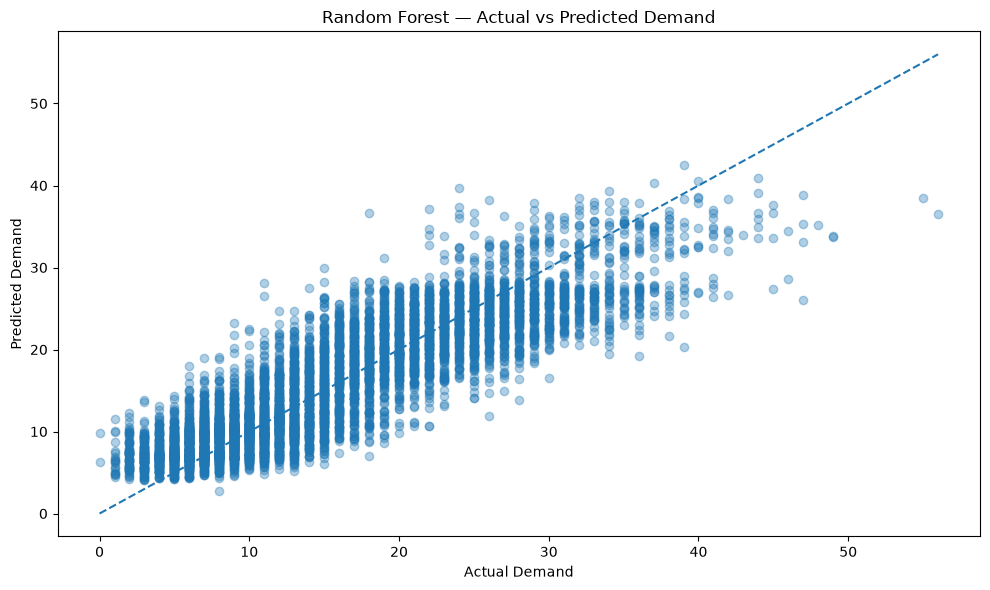

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    rf_prediction,
    alpha=0.35
)

min_value = min(y_test.min(), rf_prediction.min())
max_value = max(y_test.max(), rf_prediction.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Random Forest — Actual vs Predicted Demand")

plt.tight_layout()
plt.show()

# Cell 8 — Random Forest Feature Importance

RANDOM FOREST FEATURE IMPORTANCE

Top 20 Features:


,Feature,Importance
0,Rolling_Mean_28,0.713221
1,Rolling_Mean_14,0.065681
2,Day,0.013763
3,Day_of_Week_Sin,0.012339
4,Rolling_Std_28,0.012054
5,Rolling_Std_14,0.012030
6,Rolling_Std_7,0.011803
7,Day_of_Week,0.009895
8,is_weekend,0.009895
9,Is_Weekend,0.009817


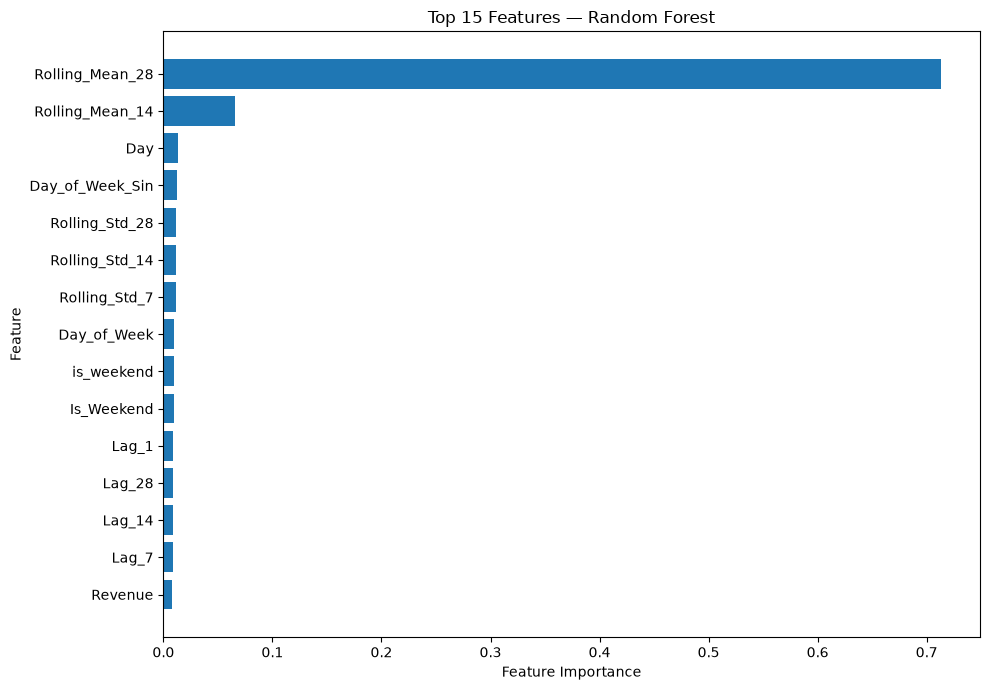


✅ Feature importance analysis completed successfully.


In [8]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("=" * 80)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 80)

print("\nTop 20 Features:")

display(
    feature_importance.head(20).style.format({
        "Importance": "{:.6f}"
    })
)

plt.figure(figsize=(10, 7))

top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features — Random Forest")

plt.tight_layout()
plt.show()

print("\n✅ Feature importance analysis completed successfully.")

# Cell 9 — Random Forest Residual / Error Analysis

RANDOM FOREST RESIDUAL ANALYSIS


,Metric,Value
0,Mean Error,-0.1652
1,Mean Absolute Error,3.1975
2,Minimum Error,-18.6258
3,Maximum Error,20.9835
4,Error Std,4.1203


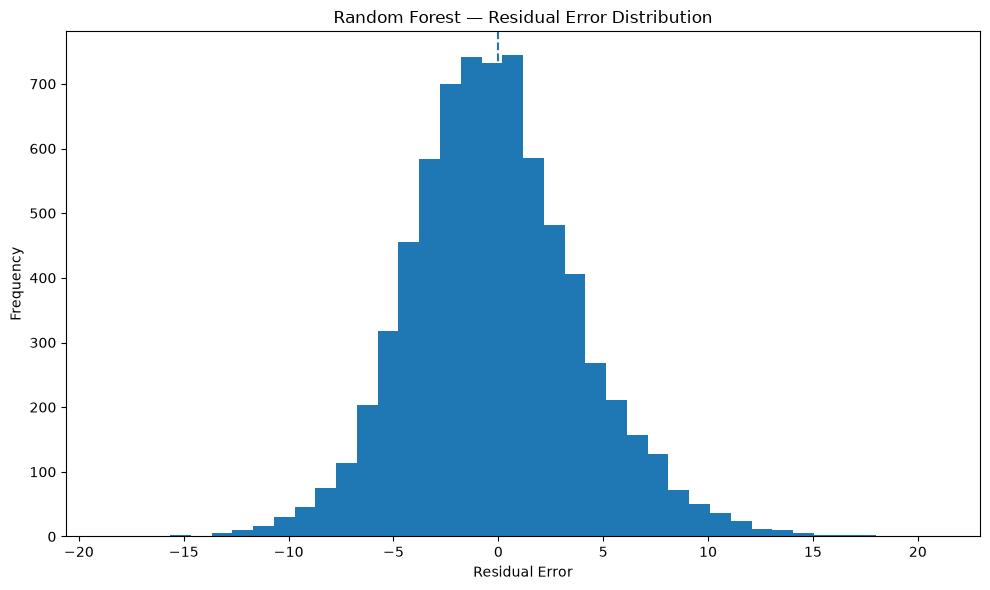

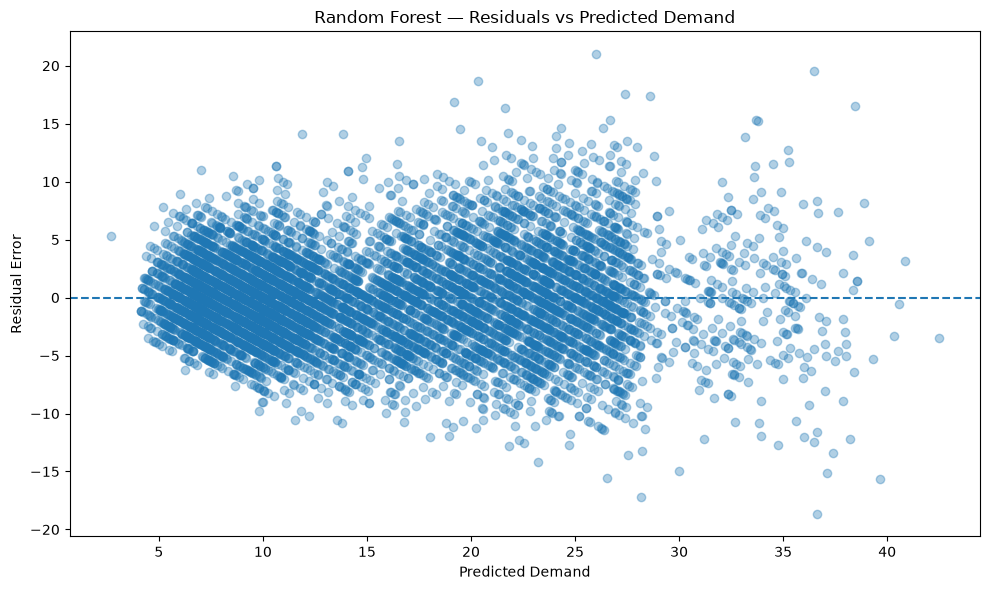


Positive residual = Actual demand was higher than predicted.
Negative residual = Actual demand was lower than predicted.

✅ Residual analysis completed successfully.


In [9]:
rf_residuals = y_test - rf_prediction

residual_metrics = pd.DataFrame({
    "Metric": [
        "Mean Error",
        "Mean Absolute Error",
        "Minimum Error",
        "Maximum Error",
        "Error Std"
    ],
    "Value": [
        rf_residuals.mean(),
        np.abs(rf_residuals).mean(),
        rf_residuals.min(),
        rf_residuals.max(),
        rf_residuals.std()
    ]
})

print("=" * 80)
print("RANDOM FOREST RESIDUAL ANALYSIS")
print("=" * 80)

display(
    residual_metrics.style.format({
        "Value": "{:.4f}"
    })
)

plt.figure(figsize=(10, 6))

plt.hist(
    rf_residuals,
    bins=40
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Residual Error")
plt.ylabel("Frequency")
plt.title("Random Forest — Residual Error Distribution")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

plt.scatter(
    rf_prediction,
    rf_residuals,
    alpha=0.35
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Demand")
plt.ylabel("Residual Error")
plt.title("Random Forest — Residuals vs Predicted Demand")

plt.tight_layout()
plt.show()

print("\nPositive residual = Actual demand was higher than predicted.")
print("Negative residual = Actual demand was lower than predicted.")

print("\n✅ Residual analysis completed successfully.")

# Cell 10 — Actual vs Predicted Demand Trend

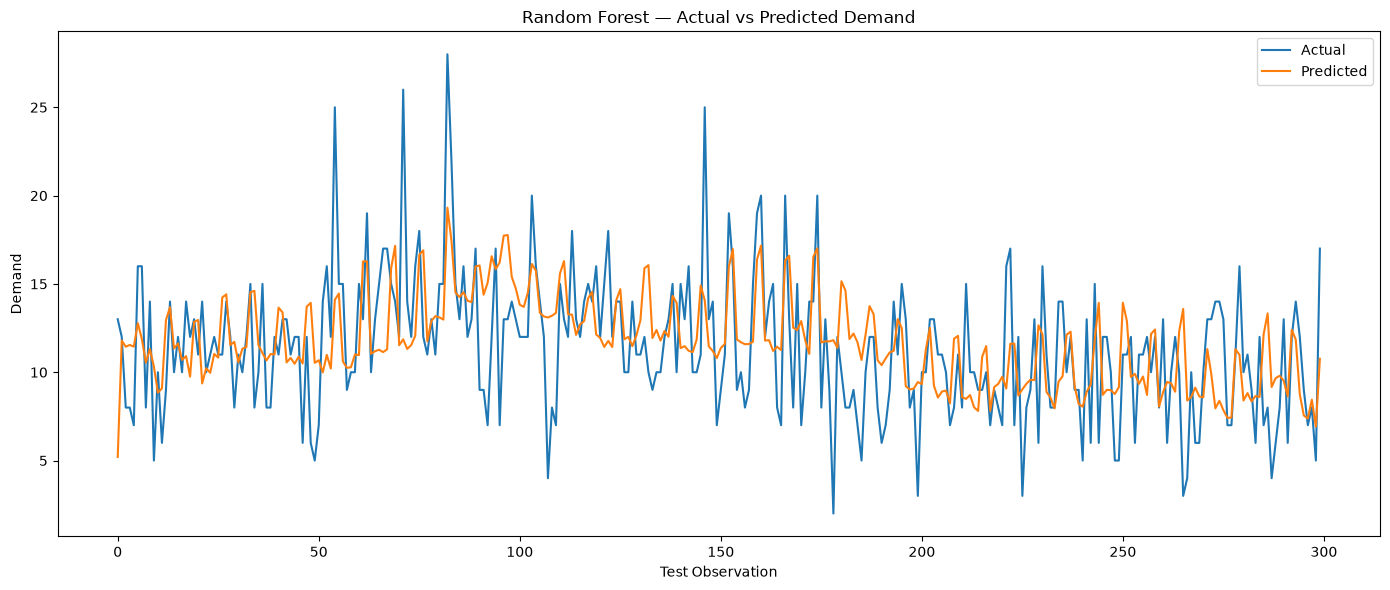

ACTUAL VS PREDICTED DEMAND ANALYSIS

Total Test Observations: 7240
Displayed Observations: 300

Actual Mean Demand: 15.52
Predicted Mean Demand: 15.69

Mean Absolute Difference: 3.1975

✅ Actual vs predicted analysis completed successfully.


In [10]:
comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": rf_prediction
})

comparison_df = comparison_df.reset_index(drop=True)

plot_points = min(300, len(comparison_df))

plt.figure(figsize=(14, 6))

plt.plot(
    comparison_df["Actual"].iloc[:plot_points],
    label="Actual"
)

plt.plot(
    comparison_df["Predicted"].iloc[:plot_points],
    label="Predicted"
)

plt.xlabel("Test Observation")
plt.ylabel("Demand")
plt.title("Random Forest — Actual vs Predicted Demand")

plt.legend()
plt.tight_layout()
plt.show()

print("=" * 80)
print("ACTUAL VS PREDICTED DEMAND ANALYSIS")
print("=" * 80)

print(f"\nTotal Test Observations: {len(comparison_df)}")
print(f"Displayed Observations: {plot_points}")

print("\nActual Mean Demand:",
      round(comparison_df["Actual"].mean(), 2))

print("Predicted Mean Demand:",
      round(comparison_df["Predicted"].mean(), 2))

print("\nMean Absolute Difference:",
      round(
          np.abs(
              comparison_df["Actual"] -
              comparison_df["Predicted"]
          ).mean(),
          4
      ))

print("\n✅ Actual vs predicted analysis completed successfully.")

# Cell 11 — Error Analysis by Demand Range

In [11]:
error_analysis_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": rf_prediction
})

error_analysis_df["Absolute_Error"] = np.abs(
    error_analysis_df["Actual"] -
    error_analysis_df["Predicted"]
)

error_analysis_df["Demand_Range"] = pd.cut(
    error_analysis_df["Actual"],
    bins=[-np.inf, 10, 20, np.inf],
    labels=["Low Demand", "Medium Demand", "High Demand"]
)

range_analysis = error_analysis_df.groupby(
    "Demand_Range",
    observed=True
).agg(
    Observations=("Actual", "count"),
    Actual_Mean=("Actual", "mean"),
    Predicted_Mean=("Predicted", "mean"),
    MAE=("Absolute_Error", "mean")
).reset_index()

print("=" * 80)
print("ERROR ANALYSIS BY DEMAND RANGE")
print("=" * 80)

display(
    range_analysis.style.format({
        "Actual_Mean": "{:.2f}",
        "Predicted_Mean": "{:.2f}",
        "MAE": "{:.4f}"
    })
)

print("\nBest Performing Demand Range:")

best_range = range_analysis.loc[
    range_analysis["MAE"].idxmin(),
    "Demand_Range"
]

print(best_range)

print("\nHighest Error Demand Range:")

worst_range = range_analysis.loc[
    range_analysis["MAE"].idxmax(),
    "Demand_Range"
]

print(worst_range)

print("\n✅ Demand range error analysis completed successfully.")

ERROR ANALYSIS BY DEMAND RANGE


,Demand_Range,Observations,Actual_Mean,Predicted_Mean,MAE
0,Low Demand,2604,6.98,8.88,2.5423
1,Medium Demand,2575,14.95,15.37,3.2255
2,High Demand,2061,27.04,24.70,3.9903



Best Performing Demand Range:
Low Demand

Highest Error Demand Range:
High Demand

✅ Demand range error analysis completed successfully.


# Cell 12 — Time-Series Cross Validation

In [12]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

tscv = TimeSeriesSplit(n_splits=5)

cv_results = []

for fold, (train_index, validation_index) in enumerate(
    tscv.split(X_train),
    start=1
):
    X_cv_train = X_train.iloc[train_index]
    X_cv_valid = X_train.iloc[validation_index]

    y_cv_train = y_train.iloc[train_index]
    y_cv_valid = y_train.iloc[validation_index]

    cv_model = RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    cv_model.fit(
        X_cv_train,
        y_cv_train
    )

    cv_prediction = cv_model.predict(
        X_cv_valid
    )

    cv_mae = mean_absolute_error(
        y_cv_valid,
        cv_prediction
    )

    cv_rmse = np.sqrt(
        mean_squared_error(
            y_cv_valid,
            cv_prediction
        )
    )

    cv_r2 = r2_score(
        y_cv_valid,
        cv_prediction
    )

    cv_results.append({
        "Fold": fold,
        "Training_Rows": len(train_index),
        "Validation_Rows": len(validation_index),
        "MAE": cv_mae,
        "RMSE": cv_rmse,
        "R2": cv_r2
    })

cv_results_df = pd.DataFrame(cv_results)

print("=" * 80)
print("TIME-SERIES CROSS VALIDATION")
print("=" * 80)

display(
    cv_results_df.style.format({
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}",
        "R2": "{:.4f}"
    })
)

print("\nAverage CV MAE:",
      round(cv_results_df["MAE"].mean(), 4))

print("Average CV RMSE:",
      round(cv_results_df["RMSE"].mean(), 4))

print("Average CV R²:",
      round(cv_results_df["R2"].mean(), 4))

print("\nMAE Standard Deviation:",
      round(cv_results_df["MAE"].std(), 4))

print("\n✅ Time-series cross-validation completed successfully.")

TIME-SERIES CROSS VALIDATION


,Fold,Training_Rows,Validation_Rows,MAE,RMSE,R2
0,1,4830,4826,5.0870,6.1905,0.4966
1,2,9656,4826,3.1477,4.0454,0.7303
2,3,14482,4826,3.0304,3.9413,0.7757
3,4,19308,4826,3.0023,3.9022,0.7362
4,5,24134,4826,2.9823,3.9094,0.8237



Average CV MAE: 3.4499
Average CV RMSE: 4.3978
Average CV R²: 0.7125

MAE Standard Deviation: 0.9174

✅ Time-series cross-validation completed successfully.


# Cell 13 — Final Random Forest Model

In [13]:
from pathlib import Path
import joblib

final_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

final_model.fit(
    X_train,
    y_train
)

final_prediction = final_model.predict(X_test)

final_mae = mean_absolute_error(
    y_test,
    final_prediction
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_prediction
    )
)

final_r2 = r2_score(
    y_test,
    final_prediction
)

non_zero_actuals = y_test != 0

if non_zero_actuals.sum() > 0:
    final_mape = np.mean(
        np.abs(
            (
                y_test[non_zero_actuals]
                - final_prediction[non_zero_actuals]
            )
            / y_test[non_zero_actuals]
        )
    ) * 100
else:
    final_mape = np.nan

final_metrics = pd.DataFrame({
    "Model": ["Final Random Forest"],
    "MAE": [final_mae],
    "RMSE": [final_rmse],
    "MAPE": [final_mape],
    "R2": [final_r2]
})

MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODEL_DIR / "random_forest_demand_model.pkl"

joblib.dump(
    final_model,
    model_path
)

print("=" * 80)
print("FINAL RANDOM FOREST MODEL")
print("=" * 80)

display(
    final_metrics.style.format({
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}",
        "MAPE": "{:.2f}%",
        "R2": "{:.4f}"
    })
)

print("\nModel saved at:")
print(model_path)

print("\nTraining rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Features:", X_train.shape[1])

print("\n✅ Final Random Forest model trained and saved successfully.")

FINAL RANDOM FOREST MODEL


,Model,MAE,RMSE,MAPE,R2
0,Final Random Forest,3.1935,4.1177,30.31%,0.7779



Model saved at:
d:\Zidio project\FORESIGHT Project\models\random_forest_demand_model.pkl

Training rows: 28960
Testing rows: 7240
Features: 130

✅ Final Random Forest model trained and saved successfully.


# Cell 14 — Final Model Validation + Prediction

In [14]:
prediction_output = pd.DataFrame({
    "Actual_Demand": y_test.values,
    "Predicted_Demand": final_prediction
})

prediction_output["Absolute_Error"] = np.abs(
    prediction_output["Actual_Demand"] -
    prediction_output["Predicted_Demand"]
)

prediction_output["Percentage_Error"] = np.where(
    prediction_output["Actual_Demand"] != 0,
    (
        prediction_output["Absolute_Error"] /
        prediction_output["Actual_Demand"]
    ) * 100,
    np.nan
)

PREDICTION_DIR = PROJECT_ROOT / "models" / "predictions"
PREDICTION_DIR.mkdir(parents=True, exist_ok=True)

prediction_path = PREDICTION_DIR / "random_forest_predictions.csv"

prediction_output.to_csv(
    prediction_path,
    index=False
)

print("=" * 80)
print("FINAL MODEL VALIDATION & PREDICTION EXPORT")
print("=" * 80)

print("\nFinal Model Metrics:")

print("MAE  :", round(final_mae, 4))
print("RMSE :", round(final_rmse, 4))
print("MAPE :", round(final_mape, 2), "%")
print("R2   :", round(final_r2, 4))

print("\nPrediction Statistics:")

print("Actual Mean Demand    :",
      round(prediction_output["Actual_Demand"].mean(), 2))

print("Predicted Mean Demand :",
      round(prediction_output["Predicted_Demand"].mean(), 2))

print("Mean Absolute Error   :",
      round(prediction_output["Absolute_Error"].mean(), 4))

print("\nPrediction Rows:",
      len(prediction_output))

print("\nSaved Prediction File:")
print(prediction_path)

print("\nSample Predictions:")
display(prediction_output.head(10))

print("\n✅ Final predictions exported successfully.")

FINAL MODEL VALIDATION & PREDICTION EXPORT

Final Model Metrics:
MAE  : 3.1935
RMSE : 4.1177
MAPE : 30.31 %
R2   : 0.7779

Prediction Statistics:
Actual Mean Demand    : 15.52
Predicted Mean Demand : 15.69
Mean Absolute Error   : 3.1935

Prediction Rows: 7240

Saved Prediction File:
d:\Zidio project\FORESIGHT Project\models\predictions\random_forest_predictions.csv

Sample Predictions:


,Actual_Demand,Predicted_Demand,Absolute_Error,Percentage_Error
0,13.0,5.130627,7.869373,60.533639
1,12.0,11.960100,0.039900,0.332504
2,8.0,11.630500,3.630500,45.381254
3,8.0,11.625223,3.625223,45.315285
4,7.0,11.272866,4.272866,61.040948
5,16.0,12.423235,3.576765,22.354778
6,16.0,11.602157,4.397843,27.486521
7,8.0,10.458079,2.458079,30.725991
8,14.0,11.131969,2.868031,20.485939
9,5.0,10.179554,5.179554,103.591085



✅ Final predictions exported successfully.


# Cell 15 — Save Final Model Metadata

In [15]:
import json

metadata = {
    "model_name": "Random Forest",
    "model_type": "RandomForestRegressor",
    "n_features": int(X_train.shape[1]),
    "training_rows": int(len(X_train)),
    "testing_rows": int(len(X_test)),
    "n_estimators": 300,
    "max_depth": 20,
    "min_samples_leaf": 2,
    "metrics": {
        "MAE": float(final_mae),
        "RMSE": float(final_rmse),
        "MAPE": float(final_mape),
        "R2": float(final_r2)
    },
    "feature_file": "models/features/feature_columns.csv",
    "model_file": "models/random_forest_demand_model.pkl",
    "prediction_file": "models/predictions/random_forest_predictions.csv"
}

metadata_path = MODEL_DIR / "random_forest_model_metadata.json"

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

print("=" * 80)
print("FINAL MODEL ARTIFACTS")
print("=" * 80)

print("\nModel:")
print(model_path)

print("\nMetadata:")
print(metadata_path)

print("\nPredictions:")
print(prediction_path)

print("\nFeatures:")
print(FEATURE_DIR / "feature_columns.csv")

print("\n✅ All final model artifacts saved successfully.")

FINAL MODEL ARTIFACTS

Model:
d:\Zidio project\FORESIGHT Project\models\random_forest_demand_model.pkl

Metadata:
d:\Zidio project\FORESIGHT Project\models\random_forest_model_metadata.json

Predictions:
d:\Zidio project\FORESIGHT Project\models\predictions\random_forest_predictions.csv

Features:
d:\Zidio project\FORESIGHT Project\models\features\feature_columns.csv

✅ All final model artifacts saved successfully.
